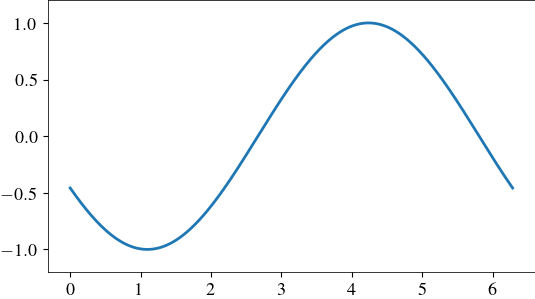

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

x = np.linspace(0, 2*np.pi, 500)
line, = ax.plot(x, np.sin(x))

ax.set_ylim(-1.2, 1.2)

def update(frame):
    line.set_ydata(np.sin(x + 0.1*frame))
    return line,

ani = FuncAnimation(
    fig,
    update,
    frames=100,
    interval=50,
    blit=True
)

ani.save("animation.gif", writer="pillow", fps=20)

# Matplotlib GIF preview and export

This notebook-local helper redraws a Matplotlib plot for each simulation timestep, previews the frames by swapping the displayed figure, and saves the same sequence as a GIF.

In [1]:
from pathlib import Path
from time import sleep

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Image, clear_output, display
import numpy as np

plt.style.use(Path("..") / "softmatter.mplstyle")

In [2]:
class MatplotlibGifBuilder:
    """Redraw a Matplotlib plot over a time-indexed data array.

    Parameters
    ----------
    plot_fn:
        Callable with signature ``plot_fn(ax, frame_data, frame_index, time, **kwargs)``.
        It should draw one timestep onto ``ax``.
    data:
        Full simulation history. The first axis is interpreted as time, so each frame
        receives ``data[frame_index]``.
    times:
        Optional physical times matching the first data axis.
    """

    def __init__(
        self,
        plot_fn,
        data,
        *,
        times=None,
        frame_indices=None,
        plot_kwargs=None,
        figsize=(6, 5),
        subplot_kw=None,
        interval_ms=120,
    ):
        self.plot_fn = plot_fn
        self.data = np.asarray(data)
        if self.data.ndim == 0:
            raise ValueError("data must have a time axis")

        self.times = np.arange(self.data.shape[0]) if times is None else np.asarray(times)
        if len(self.times) != self.data.shape[0]:
            raise ValueError("times must have the same length as data's first axis")

        if frame_indices is None:
            self.frame_indices = np.arange(self.data.shape[0])
        else:
            self.frame_indices = np.asarray(frame_indices, dtype=int)

        self.plot_kwargs = {} if plot_kwargs is None else dict(plot_kwargs)
        self.figsize = figsize
        self.subplot_kw = {} if subplot_kw is None else dict(subplot_kw)
        self.interval_ms = interval_ms

    def _new_figure(self):
        return plt.subplots(figsize=self.figsize, subplot_kw=self.subplot_kw)

    def _draw_on_axis(self, ax, frame_index):
        self.plot_fn(
            ax,
            self.data[frame_index],
            int(frame_index),
            self.times[frame_index],
            **self.plot_kwargs,
        )

    def preview(self, max_frames=None):
        """Preview frames in a notebook by actively swapping Matplotlib figures."""
        frame_indices = self.frame_indices[:max_frames]
        for frame_index in frame_indices:
            fig, ax = self._new_figure()
            self._draw_on_axis(ax, frame_index)
            clear_output(wait=True)
            display(fig)
            plt.close(fig)
            sleep(self.interval_ms / 1000)

    def save(self, output_path, *, fps=None, dpi=120, preview_saved=True):
        """Save the redrawn timesteps as a GIF using Pillow."""
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fps = 1000 / self.interval_ms if fps is None else fps

        fig, ax = self._new_figure()

        def update(frame_index):
            ax.clear()
            self._draw_on_axis(ax, frame_index)
            return ax.get_children()

        anim = animation.FuncAnimation(
            fig,
            update,
            frames=self.frame_indices,
            interval=self.interval_ms,
            blit=False,
        )
        anim.save(output_path, writer=animation.PillowWriter(fps=fps), dpi=dpi)
        plt.close(fig)

        if preview_saved:
            display(Image(filename=str(output_path)))
        return output_path


def make_time_gif(plot_fn, data, output_path, **kwargs):
    """Convenience wrapper around ``MatplotlibGifBuilder(...).save(...)``."""
    return MatplotlibGifBuilder(plot_fn, data, **kwargs).save(output_path)

In [3]:
# Small synthetic trajectory history with the same convention used by the simulations:
# shape = (n_times, dim, n_particles)
rng = np.random.default_rng(4)
n_times = 80
n_particles = 250
steps = 0.08 * rng.normal(size=(n_times, 2, n_particles))
r_demo = np.cumsum(steps, axis=0)
times_demo = np.linspace(0, 8, n_times)

In [4]:
def plot_swimmer_snapshot(ax, frame_data, frame_index, time, *, xlim=(-3, 3), ylim=(-3, 3)):
    """Draw one frame. Replace this function with any per-timestep plot you want."""
    x, y = frame_data[0], frame_data[1]
    ax.scatter(x, y, s=10, alpha=0.65, linewidths=0)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Swimmer positions | frame {frame_index:03d} | t = {time:.2f}")
    ax.grid(True, alpha=0.2)

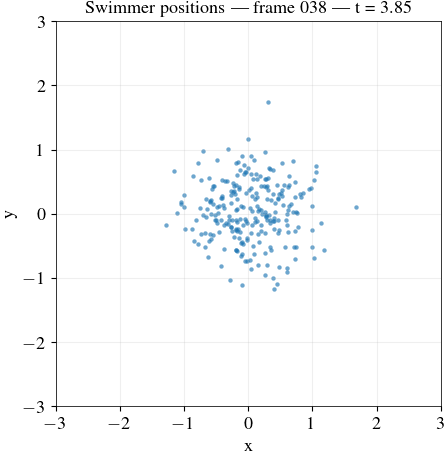

In [5]:
gif_builder = MatplotlibGifBuilder(
    plot_swimmer_snapshot,
    r_demo,
    times=times_demo,
    frame_indices=np.arange(0, n_times, 2),
    interval_ms=90,
)

# Actively swaps Matplotlib plots in the notebook output.
gif_builder.preview(max_frames=20)

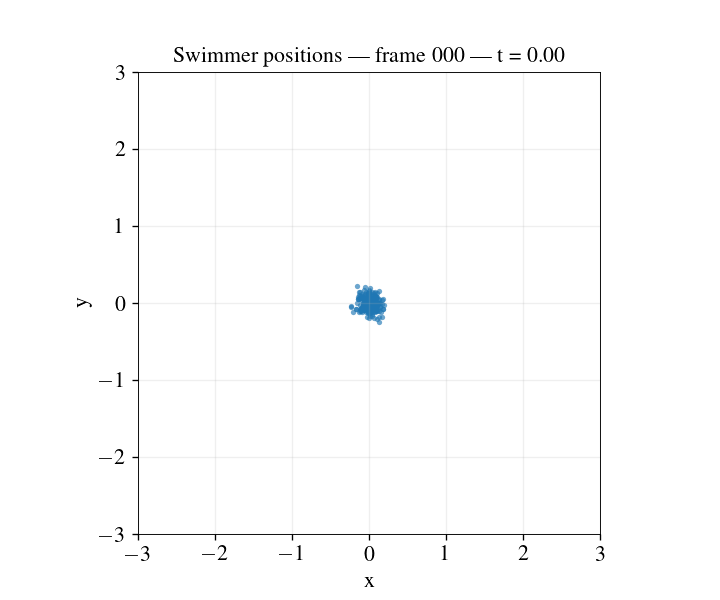

WindowsPath('../outputs/visualization_test/swimmer_positions.gif')

In [6]:
gif_path = gif_builder.save(Path("..") / "outputs" / "visualization_test" / "swimmer_positions.gif")
gif_path

To use this with simulation output, pass the full history array directly, for example `MatplotlibGifBuilder(plot_swimmer_snapshot, results["r"], times=t_steps).save(...)`. If your plot is a histogram or density view, write a small `plot_fn(ax, frame_data, frame_index, time, **kwargs)` that draws that single frame onto the supplied axis.